# VLM + SAM3 Playground

Manual experiments on a **single ego–exo image pair** to explore VLM and SAM3 behaviour. Required logic is inlined in the notebook for easier debugging.

* Bounding box precise on object vs padding to include context; does not matter, VLM recognises reb box and is able to describe context around it. 
* VLM describe only target object vs describe target object and context; VLM succseeds, SAM3 fails. 
* SAM3 performance with short descruption vs longer description; SAM3 performs better with super-short descriptions. 
* SAM3 performance with text prompt vs bounding box; how to use VLM to achieve cross correspondence. 
* SAM3 and VLM performance with occlusions. 


## 1. Set up: libraries and API keys

In [3]:
import os
import base64
import numpy as np
import cv2
import torch
from pathlib import Path
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from ollama import Client
from huggingface_hub import login
from PIL import Image
import matplotlib.pyplot as plt
from transformers import Sam3Processor, Sam3Model

# Project root (for env and paths)
ROOT = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent

In [4]:
def _get_api_keys(cfg, list_key, provider_name):
    keys = cfg.get(list_key)
    if not isinstance(keys, list) or not keys:
        raise ValueError(f"Missing {provider_name} API keys. Set {list_key} in config.")
    cleaned = [k.strip() for k in keys if isinstance(k, str) and k.strip()]
    if not cleaned:
        raise ValueError(f"No valid {provider_name} API keys in `{list_key}`.")
    return cleaned


def file_to_b64(path):
    """Base64-encode an image file on disk."""
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()


def init_vlm(cfg):
    keys = _get_api_keys(cfg, "vlm-api-keys", "Ollama")
    return {
        "keys": keys,
        "idx": 0,
        "client": Client(host="https://ollama.com", headers={"Authorization": f"Bearer {keys[0]}"}),
    }


def vlm_caption(vlm_state, model, images_b64, prompt):
    msgs = [{"role": "user", "content": prompt, "images": images_b64}]
    text = ""
    for part in vlm_state["client"].chat(
        model=model, messages=msgs, stream=True, options={"temperature": 0, "seed": 777, "num_predict": 32}
    ):
        text += part.message.content
    return text.strip()


def init_sam3(cfg):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    name = cfg["huggingface-model"]
    keys = _get_api_keys(cfg, "huggingface-api-keys", "Hugging Face")
    for key in keys:
        try:
            login(token=key)
            model = Sam3Model.from_pretrained(name).to(device)
            proc = Sam3Processor.from_pretrained(name)
            return model, proc, device
        except Exception as e:
            if key is keys[-1]:
                raise RuntimeError("Failed to initialize SAM3 with all Hugging Face API keys.") from e
            continue


def sam3_segment(model, proc, img_path, text_prompt, device):
    """Run text-prompted SAM3 segmentation. Returns dict with 'masks' and optionally 'scores'."""
    img = Image.open(img_path).convert("RGB")
    inputs = proc(images=img, text=text_prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**inputs)
    result = proc.post_process_instance_segmentation(
        out, 
        threshold=0.2, 
        mask_threshold=0.5, 
        target_sizes=inputs.get("original_sizes").tolist()
        )[0]
    return result

def visualise_sam_masks(image_path, sam_out, alpha=0.4):
    """Overlay SAM3 masks on image. sam_out has 'masks' (list of tensors) and optionally 'scores'."""
    img = np.array(Image.open(image_path).convert("RGB"))
    h, w = img.shape[:2]
    out = img.copy().astype(np.float32)
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]
    masks = sam_out.get("masks", [])
    for i, m in enumerate(masks):
        mask_np = m.cpu().numpy()
        if mask_np.ndim == 3:
            mask_np = mask_np.squeeze()
        if mask_np.shape[0] != h or mask_np.shape[1] != w:
            mask_np = cv2.resize(
                mask_np.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST
            ).astype(bool)
        else:
            mask_np = mask_np.astype(bool)
        color = colors[i % len(colors)]
        out[mask_np] = out[mask_np] * (1 - alpha) + np.array(color) * alpha
    return np.clip(out, 0, 255).astype(np.uint8)


In [5]:
load_dotenv(ROOT / "env.env")

VLM_API_KEYS = os.environ.get("OLLAMA_API_KEY", "").strip()
HF_API_KEYS = os.environ.get("HF_TOKEN", "").strip()

if isinstance(VLM_API_KEYS, str):
    VLM_API_KEYS = [k for k in VLM_API_KEYS.split(",") if k.strip()]
if isinstance(HF_API_KEYS, str):
    HF_API_KEYS = [k for k in HF_API_KEYS.split(",") if k.strip()]

VLM_MODEL = "qwen3-vl:235b-cloud"
HF_MODEL = "facebook/sam3"

config = {
    "vlm-api-keys": VLM_API_KEYS,
    "huggingface-api-keys": HF_API_KEYS,
    "vlm-model": VLM_MODEL,
    "huggingface-model": HF_MODEL,
}

# Initialize (run after config is set)
vlm_state = init_vlm(config)
sam_model, sam_processor, device = init_sam3(config)
print(f"VLM: {VLM_MODEL}, SAM3 on {device}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

VLM: qwen3-vl:235b-cloud, SAM3 on cpu


## 2. Inference: single ego–exo pair

### 2.1 Img Paths

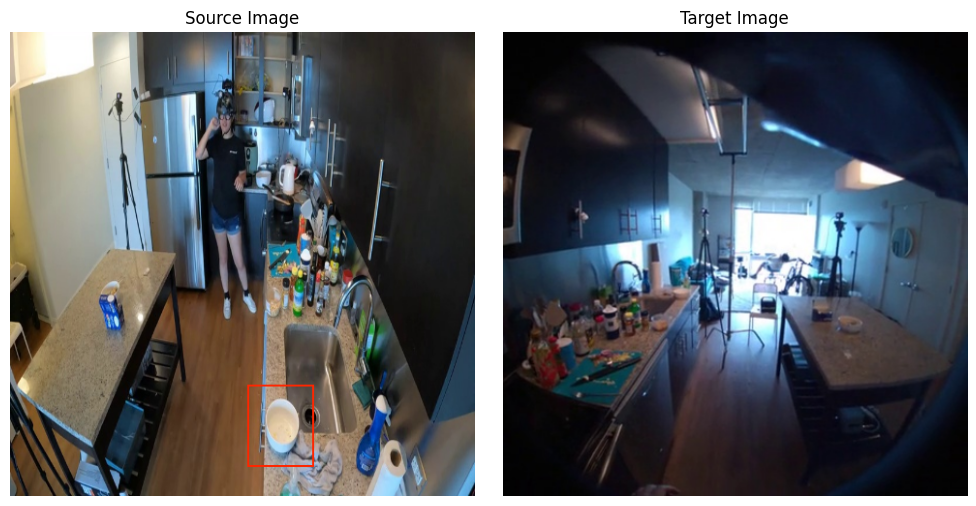

In [154]:
source_img = "../local_misc/LMEEC-failure-cases/egoexo-clean/iou0_cooking_large_0efd9fc1_f1650_box.png"
target_img = "../local_misc/LMEEC-failure-cases/egoexo-clean/iou0_cooking_large_0efd9fc1_f1650_cross.png"

# Load images
img1 = Image.open(source_img)
img2 = Image.open(target_img)

# Visualise side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img1)
axes[0].set_title("Source Image")
axes[0].axis('off')

axes[1].imshow(img2)
axes[1].set_title("Target Image")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 2.2 VLM prompt

In [146]:
VLM_PROMPT = (""" 
    Task: describe concisely the object contained exactly inside the red box.
    Use the image to understand what the object is specifically and how it relates to the nearest objects around it.
    Use descriptos that are view indepent such that the description of the object applies from any angle in the room it is looked at: near, in, held by, etc.
    Answer with: {main colours} {object}, {view-independent descriptors}.
    """)

### 2.3 Build VLM input images and call VLM

In [151]:
images_b64 = [file_to_b64(Path(source_img).resolve())]
vlm_output = vlm_caption(vlm_state, VLM_MODEL, images_b64, VLM_PROMPT)
attempts = 0
while vlm_output == "" and attempts < 3:
    vlm_output = vlm_caption(vlm_state, VLM_MODEL, images_b64, VLM_PROMPT)
    attempts += 1
print("VLM output:\n", vlm_output)

VLM output:
 silver knife, on the blue cutting board among chopped food pieces


In [155]:
vlm_output = "white bowl near the metal sink and the blue spray bottle"

### 2.4 SAM3 call

In [156]:
text_prompt = vlm_output.strip()

target_path = str(Path(target_img).resolve())
sam_out = sam3_segment(sam_model, sam_processor, target_path, text_prompt, device)

print("Number of masks:", len(sam_out["masks"]))
print("Scores:", [round(float(s), 3) for s in sam_out["scores"]])

Number of masks: 0
Scores: []


### 2.5 SAM3: visualise results

Overlay predicted masks on the exo image.

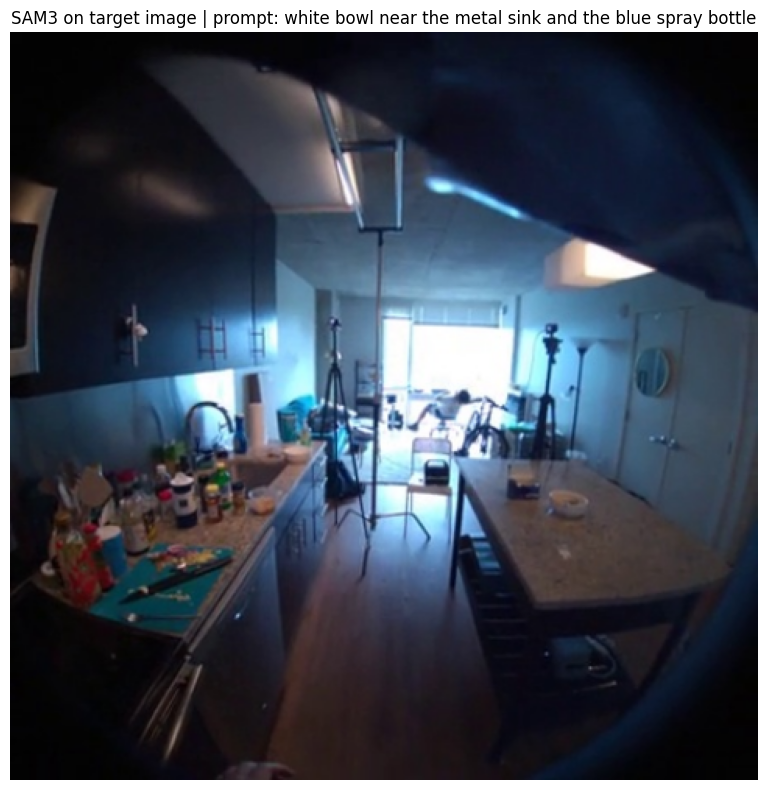

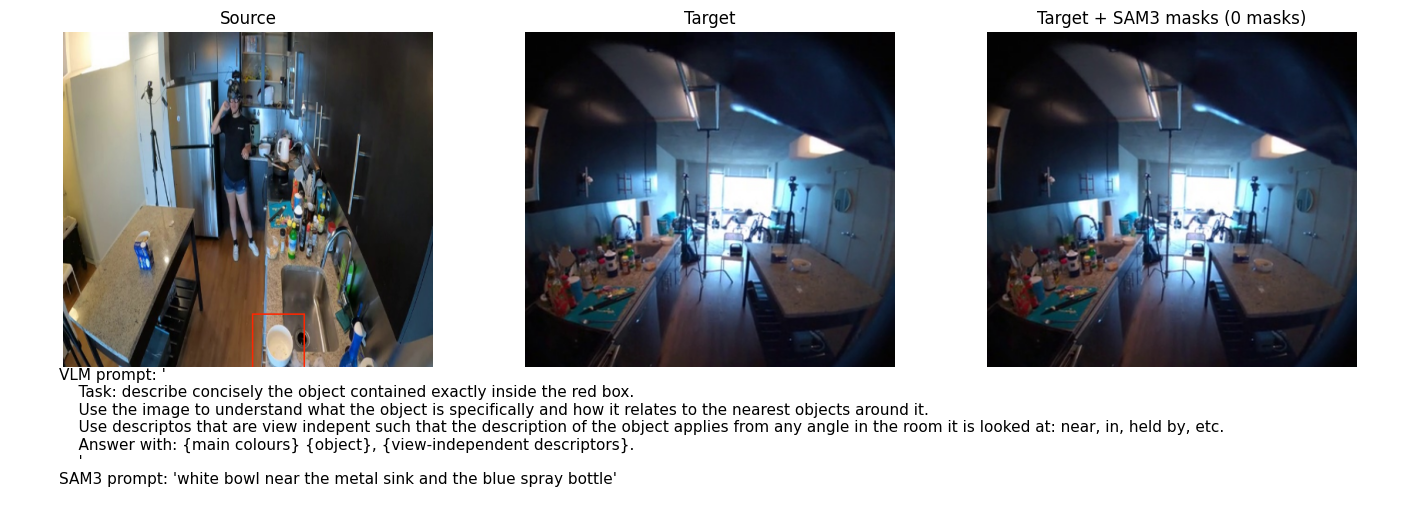

In [157]:
overlay_img = visualise_sam_masks(target_path, sam_out)
n_masks = len(sam_out.get("masks", []))
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(overlay_img)
ax.set_title(f"SAM3 on target image | prompt: {text_prompt}")
ax.axis("off")
plt.tight_layout()
plt.show()

# Side-by-side: ego, exo, exo with SAM3 overlay
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(Image.open(source_img))
axes[0].set_title("Source")
axes[0].axis("off")
axes[1].imshow(Image.open(target_path))
axes[1].set_title("Target")
axes[1].axis("off")
axes[2].imshow(overlay_img)
axes[2].set_title(f"Target + SAM3 masks ({n_masks} mask{'s' if n_masks != 1 else ''})")
axes[2].axis("off")
plt.tight_layout()
# Add VLM and SAM3 prompt below the plots
# Add white footer space to make the prompt readable
from matplotlib.patches import Rectangle

# Increase figure size to make space at the bottom
fig.subplots_adjust(bottom=0.23)

# Add white rectangle footer spanning the width of the figure
footer_height_frac = 0.30
fig.patches.extend([
    Rectangle(
        (0, 0), 1, footer_height_frac,
        transform=fig.transFigure, figure=fig,
        facecolor='white', edgecolor='none', zorder=21)
])

# Add the prompt text in the white footer
fig.text(
    0.035, 0.06,
    f"VLM prompt: '{VLM_PROMPT}'\nSAM3 prompt: '{vlm_output}'",
    ha='left', va='bottom',
    fontsize=11, color='black', wrap=True, zorder=22
)

plt.show()